In [ ]:
# here we do EDA and visuvalization of the data on the date file pre Processed Uber drivers data 
# which is cleaned and preprocessed data

# see we have the data that only focus on the one driver on uber who's rides in one year which 2016

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
path = "preProcessedUberDrivers2016.csv"
df = pd.read_csv(path)


In [7]:
# so lets se in which month he took more rides
df.columns


Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE', 'START_YEAR', 'START_MONTH', 'START_DAY', 'START_HOUR',
       'DAY_NAME'],
      dtype='object')

In [16]:
df['START_MONTH'].value_counts().sort_index(ascending=True)

START_MONTH
1      61
2     115
3     113
4      54
5      49
6     107
7     112
8     133
9      36
10    106
11    122
12    146
Name: count, dtype: int64

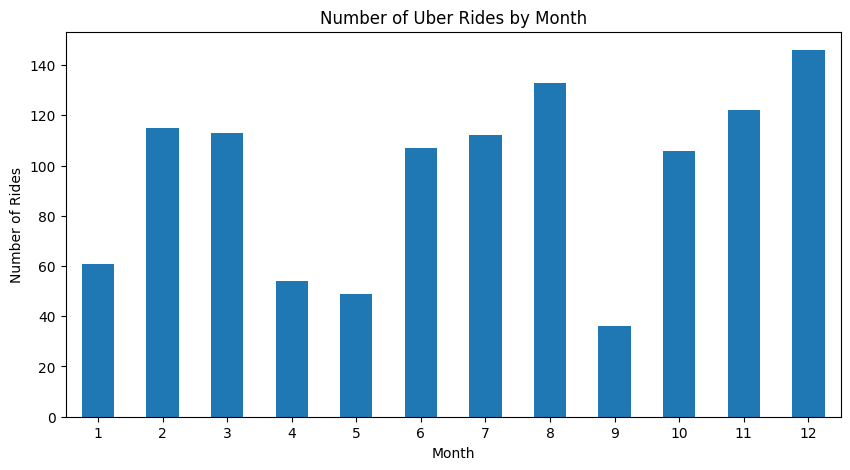

In [22]:
monthly_rides = df['START_MONTH'].value_counts().sort_index()

monthly_rides.plot(kind='bar', figsize=(10, 5))

plt.title('Number of Uber Rides by Month')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.show()

In [26]:
# lets see in month of December in each day how many rides driver took
dec_rows = df[df['START_MONTH'] == 12]
dec_daily_rides = dec_rows['START_DAY'].value_counts().sort_index(ascending=True)
print(dec_daily_rides)

START_DAY
1      4
2      4
3      3
4      2
5      2
7      4
8      4
9      4
10     4
11     3
12     5
13     2
14     4
15     1
17     2
18     3
19    11
20     8
21    10
22     9
23     5
24     8
25     3
26     5
27     6
28     7
29    13
30     5
31     5
Name: count, dtype: int64


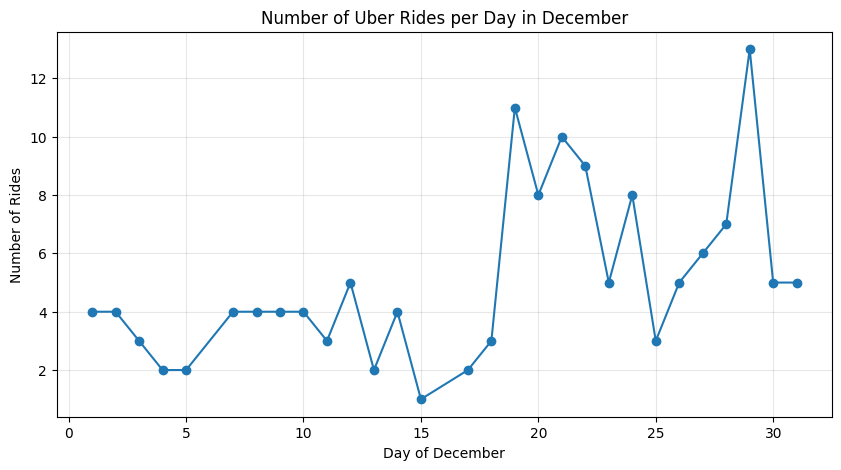

In [47]:
# Rides per day in the month of December
dec_daily_rides.plot(
    kind='line',
    figsize=(10, 5),
    marker='o'
)

plt.title('Number of Uber Rides per Day in December')
plt.xlabel('Day of December')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)

plt.show()


In [39]:
# MAy Day name wise.
may_rows = df[df['START_MONTH'] == 5]
may_daily_rides = may_rows['DAY_NAME'].value_counts().sort_index()
print(may_daily_rides)


DAY_NAME
Friday       8
Monday       8
Saturday     5
Sunday       7
Thursday     4
Tuesday      9
Wednesday    8
Name: count, dtype: int64


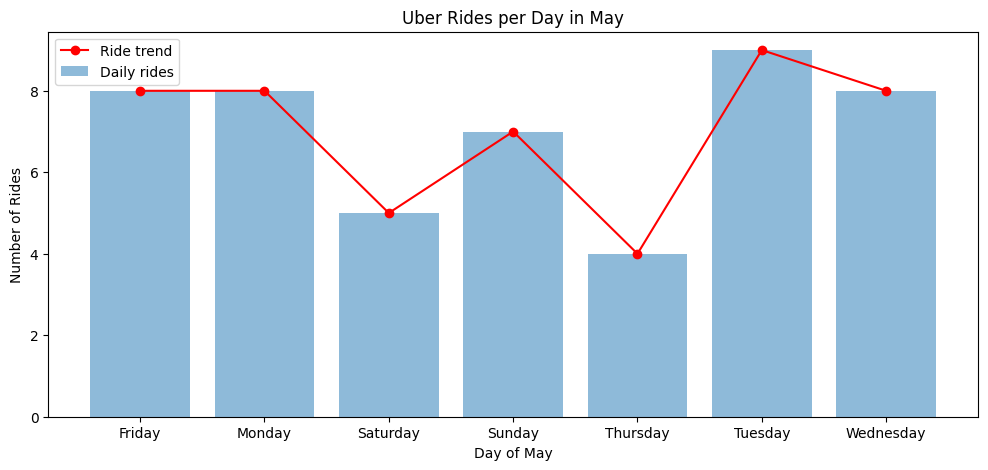

In [48]:


plt.figure(figsize=(12, 5))

# Bar graph
plt.bar(
    may_daily_rides.index,
    may_daily_rides.values,
    alpha=0.5,
    label='Daily rides'
)

# Line graph
plt.plot(
    may_daily_rides.index,
    may_daily_rides.values,
    marker='o',
    color='red',
    label='Ride trend'
)

plt.title('Uber Rides per Day in May')
plt.xlabel('Day of May')
plt.ylabel('Number of Rides')

plt.xticks(may_daily_rides.index)
plt.legend()

plt.show()

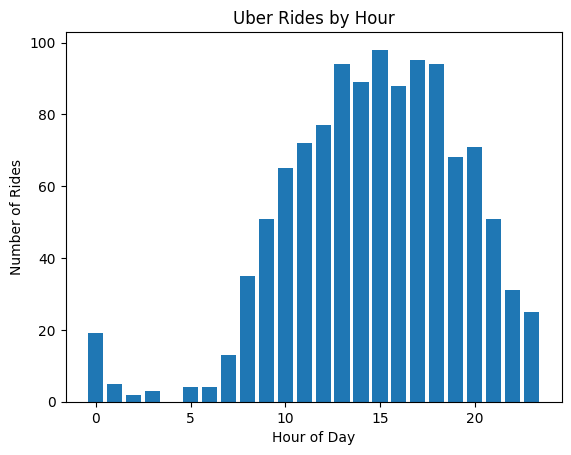

In [43]:
# at what hour rides are high
rides_by_hour = df["START_HOUR"].value_counts().sort_index()

plt.bar(rides_by_hour.index, rides_by_hour.values)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.title("Uber Rides by Hour")

plt.show()

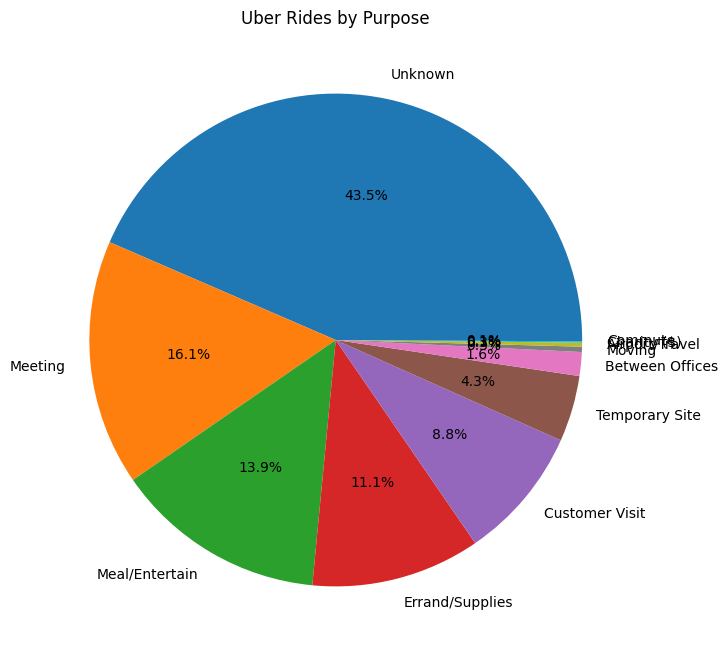

In [45]:
# pie chart of purposes based ride
df['PURPOSE'].value_counts().plot(
    kind='pie',
    figsize=(8, 8),
    autopct='%1.1f%%'
)

plt.title('Uber Rides by Purpose')
plt.ylabel('')
plt.show()

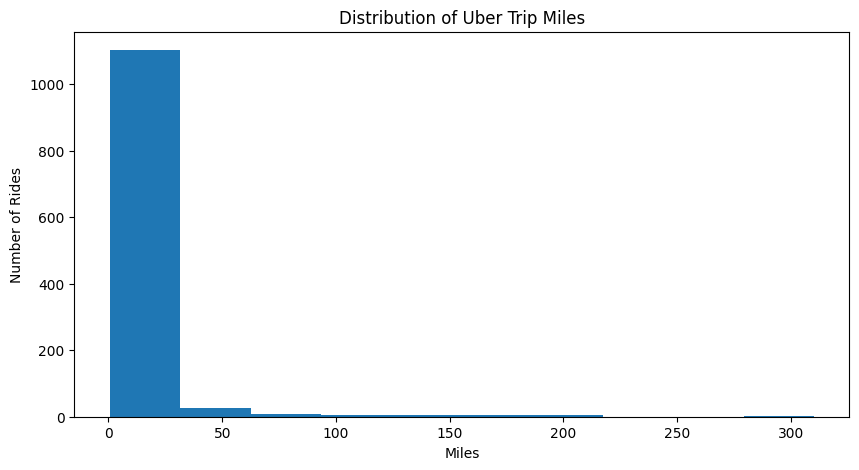

In [46]:
# miles distribution
plt.figure(figsize=(10, 5))

plt.hist(df['MILES'], bins=10)

plt.title('Distribution of Uber Trip Miles')
plt.xlabel('Miles')
plt.ylabel('Number of Rides')

plt.show()


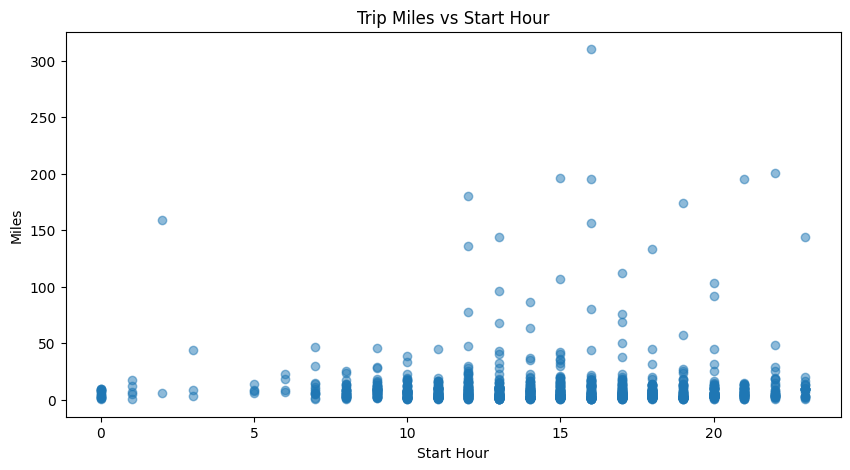

In [35]:
# At which hour miles are high based on scatter plot

plt.figure(figsize=(10, 5))

plt.scatter(df['START_HOUR'], df['MILES'], alpha=0.5)

plt.title('Trip Miles vs Start Hour')
plt.xlabel('Start Hour')
plt.ylabel('Miles')

plt.show()


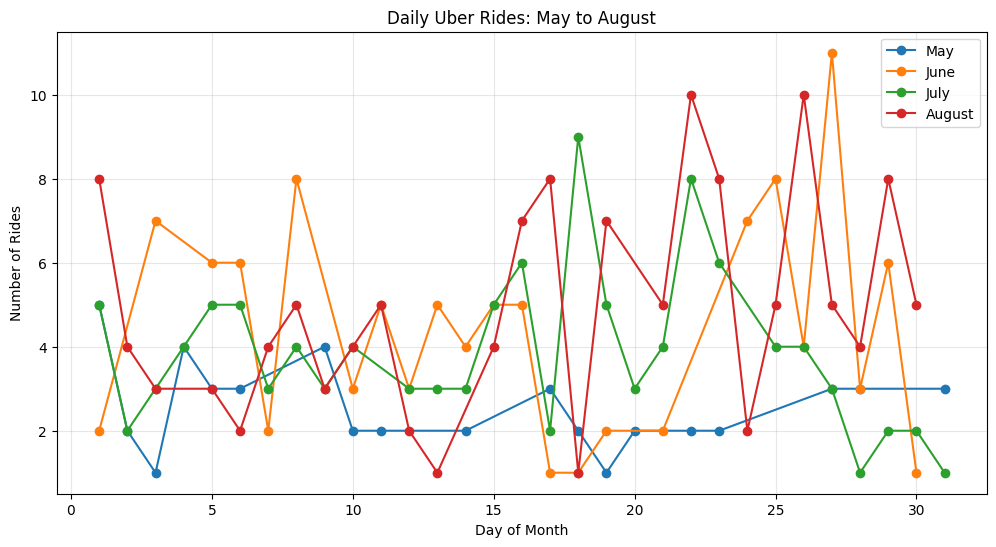

In [50]:
# Four months on the same graph

months = [5, 6, 7, 8]
month_names = ['May', 'June', 'July', 'August']

plt.figure(figsize=(12, 6))

for month, name in zip(months, month_names):

    month_rows = df[df['START_MONTH'] == month]

    daily_rides = month_rows['START_DAY'].value_counts().sort_index()

    plt.plot(
        daily_rides.index,
        daily_rides.values,
        marker='o',
        label=name
    )

plt.title('Daily Uber Rides: May to August')
plt.xlabel('Day of Month')
plt.ylabel('Number of Rides')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()